> **Versão pública.** Este notebook rodou no Google Colab, com os dados e artefatos numa pasta do Google Drive do grupo. Para reproduzir, veja [Como reproduzir](../README.md#como-reproduzir).

# Imports e Configuração de Ambiente

In [1]:
path_notebook = '/content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/01-Baseline/'

In [2]:
from google.colab import drive

import os
import sys

import pandas as pd
import numpy as np
from PIL import Image, ImageOps

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import gc

import tensorflow as tf

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

from sklearn import metrics

import matplotlib.cm as cm
from matplotlib.colors import ListedColormap

In [3]:
drive.mount('/content/drive', force_remount = True)
#drive.flush_and_unmount()

Mounted at /content/drive


# Acessando API do Kaggle, Download e Extração do Dataset

In [4]:
#Instala a API
!pip install kaggle

In [5]:
# Move minhas credenciais para a pasta em que a API foi instalada
!mkdir -p ~/.kaggle/ && cp -i /content/drive/My Drive/<PASTA_DO_PROJETO>/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [6]:
#Baixa dos dados do Projeto, descompacta e deleta arquivo zip
!kaggle datasets download --force -d paultimothymooney/kermany2018 && unzip kermany2018.zip && rm kermany2018.zip

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8050636-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-3.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-3.jpeg  
[... 4985 linhas omitidas na versão pública ...]
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-4872585-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5156112-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5171640-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5193994-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val

# Visualização dos Dados

In [ ]:
!ls /content/OCT2017\ /train/NORMAL | head -5

NORMAL-1001666-1.jpeg
NORMAL-1001772-1.jpeg
NORMAL-1001772-2.jpeg
NORMAL-1001772-3.jpeg
NORMAL-1001772-4.jpeg


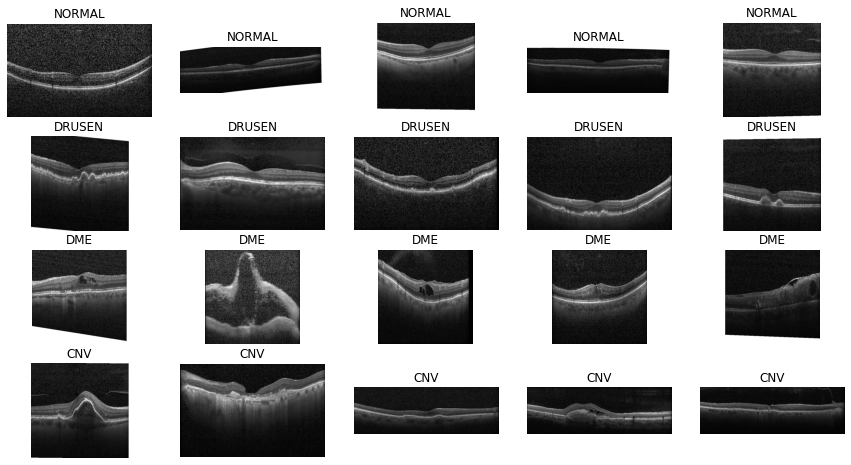

In [ ]:
labels_folders = ['NORMAL', 'DRUSEN', 'DME', 'CNV']
num_img = 5

fig, ax = plt.subplots(len(labels_folders), num_img, figsize = (int(3*num_img), 2*len(labels_folders)))
for j in range(0, len(labels_folders)):
  label = labels_folders[j]
  path = '/content/OCT2017 /train/' + label + '/'
  lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
  for i in range(0, num_img):
      img_matrix = np.matrix(Image.open(path + lista_imagens[i]))
      ax[j][i].imshow(img_matrix, cmap='gray', vmin = 0, vmax = 255)
      ax[j][i].set_title(label)
      ax[j][i].set_axis_off()
plt.show()

# Analise do Dataset

In [ ]:
#Cria datafame com as informações dos arquivos do dataset (não precisa rodar de novo - salvo em CSV)

list_splits = ['train', 'val', 'test']
labels_folders = ['NORMAL', 'DRUSEN', 'DME', 'CNV']

df = pd.DataFrame(columns = ['Conjunto', 'Label_Pasta', 'Label_Arquivo', 'ID_Paciente', 'Num_Imagem'])

for k in range(0, len(list_splits)):
  conjunto = list_splits[k]
  for j in range(0, len(labels_folders)):
    label_pasta = labels_folders[j]
    path = '/content/OCT2017 /' + conjunto + '/' + label_pasta + '/'
    lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
    for i in range(0, len(lista_imagens)):
        df.loc[len(df)] = np.append([conjunto, label_pasta], lista_imagens[i][:-5].split('-'))

df.to_csv(path_notebook + 'dataset_imagens.csv', index = False)
display(df)

Conjunto Label_Pasta Label_Arquivo ID_Paciente Num_Imagem
0        train      NORMAL        NORMAL     5699128         36
1        train      NORMAL        NORMAL     7641896          3
2        train      NORMAL        NORMAL     8099138          4
3        train      NORMAL        NORMAL     4055810          8
4        train      NORMAL        NORMAL     3997725          7
...        ...         ...           ...         ...        ...
84479     test         CNV           CNV     2959614          3
84480     test         CNV           CNV     1632795          1
84481     test         CNV           CNV     4244160          3
84482     test         CNV           CNV     1699976          1
84483     test         CNV           CNV     1415351          1

[84484 rows x 5 columns]

In [7]:
df = pd.read_csv(path_notebook + 'dataset_imagens.csv')

In [8]:
#Função Auxiliar para criar o caminho da imagem com base das informações do dataframe
def cria_path_img(linha):
  path = linha['Conjunto'] + '/' + linha['Label_Pasta'] + '/' + linha['Label_Arquivo'] + '-' + str(linha['ID_Paciente']) + '-' + str(linha['Num_Imagem']) + '.jpeg'
  return path

classes = ['CNV','DME','DRUSEN', 'NORMAL']

#Função para definir o padrão do nosso One Hot Enconder
def one_hot_encoder(y):
  if(y == 'CNV'):
    return [1, 0, 0, 0]
  elif(y == 'DME'):
    return [0, 1, 0, 0]
  elif(y == 'DRUSEN'):
    return [0, 0, 1, 0]
  elif(y == 'NORMAL'):
    return [0, 0, 0, 1]

#Função para inverter o One Hot Encoder
def inverse_one_hot_encoder_labels(y):
  if(np.argmax(y) == 0):
    return 'CNV'
  elif(np.argmax(y) == 1):
    return 'DME'
  elif(np.argmax(y) == 2):
    return 'DRUSEN'
  elif(np.argmax(y) == 3):
    return 'NORMAL'

#Converte a posição do vetor de One Hot Encoder no Label que ele representa
def numeric_to_string(y):
  if(y == 0):
    return 'CNV'
  elif(y == 1):
    return 'DME'
  elif(y == 2):
    return 'DRUSEN'
  elif(y == 3):
    return 'NORMAL'

In [9]:
#Checa a quantidade de imagens (tem 84484 e não 84495 como diz o kaggle!!)
print(len(df))

84484


In [10]:
#Checa se tem Labels incoerentes entre o nome da pasta e o nome do arquivo (Não tem!!)
print(np.sum(df['Label_Pasta'] != df['Label_Arquivo']))

0


In [11]:
#Agrupamento para analisar o dataset por paciente
def f(x):
  d = {}
  d['QTD_Arquivos_Imgs'] = len(x)
  d['QTD_Num_Imagens'] = len(x['Num_Imagem'].unique())
  d['QTD_train'] = np.sum(x['Conjunto'] == 'train')
  d['QTD_val'] = np.sum(x['Conjunto'] == 'val')
  d['QTD_test'] = np.sum(x['Conjunto'] == 'test')
  d['QTD_NORMAL'] = np.sum(x['Label_Arquivo'] == 'NORMAL')
  d['QTD_DME'] = np.sum(x['Label_Arquivo'] == 'DME')
  d['QTD_DRUSEN'] = np.sum(x['Label_Arquivo'] == 'DRUSEN')
  d['QTD_CNV'] = np.sum(x['Label_Arquivo'] == 'CNV')
  return pd.Series(d)

df_agrup = df.groupby('ID_Paciente').apply(lambda x: f(x))

In [12]:
#Quantidade de ID_Paciente distintos
print(len(df_agrup))

4657


In [13]:
#Pacientes que mais tem arquivos de imagens
df_agrup.sort_values('QTD_Arquivos_Imgs', ascending = False)[:10]

QTD_Arquivos_Imgs  QTD_Num_Imagens  ...  QTD_DRUSEN  QTD_CNV
ID_Paciente                                      ...                     
1188386                    817              813  ...           0      817
6652117                    614              613  ...           0      614
6666538                    585              585  ...           0      585
172472                     470              459  ...           0      470
7907754                    469              469  ...           0      469
9374492                    459              459  ...           0      459
1699976                    444              396  ...           0      401
1112835                    407              382  ...          23      384
9642260                    382              315  ...          66      315
1997439                    377              230  ...         140      237

[10 rows x 9 columns]

In [14]:
#Paciente estranho (tem imagens com doenças distintas)
df[df['ID_Paciente'] == 1112835].groupby(['ID_Paciente', 'Num_Imagem']).apply(lambda x: f(x)).sort_values('QTD_Arquivos_Imgs', ascending = False)[:10]

QTD_Arquivos_Imgs  QTD_Num_Imagens  ...  QTD_DRUSEN  QTD_CNV
ID_Paciente Num_Imagem                                      ...                     
1112835     1                           4                1  ...           2        2
            2                           3                1  ...           1        2
            13                          2                1  ...           1        1
            21                          2                1  ...           1        1
            20                          2                1  ...           1        1
            19                          2                1  ...           1        1
            18                          2                1  ...           1        1
            17                          2                1  ...           1        1
            16                          2                1  ...           1        1
            15                          2                1  ...           1        1

[10 rows x 9 columns]

Conjunto  ...                                            Caminho
33296    train  ...  /content/OCT2017 /train/DRUSEN/DRUSEN-1112835-...
62133    train  ...     /content/OCT2017 /train/CNV/CNV-1112835-1.jpeg
83947     test  ...  /content/OCT2017 /test/DRUSEN/DRUSEN-1112835-1...
84354     test  ...      /content/OCT2017 /test/CNV/CNV-1112835-1.jpeg

[4 rows x 6 columns]

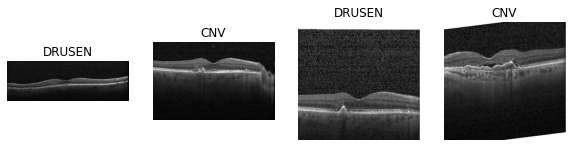

In [15]:
#Imagens estranhas do paciente estranho (duas imagens parecem do mesmo olho mas estão com anotações distintas)

df_imgs = df[(df['ID_Paciente'] == 1112835) & (df['Num_Imagem'] == 1)].copy()
path_raiz = '/content/OCT2017 /'
df_imgs['Caminho'] = df_imgs.apply(lambda x: path_raiz + cria_path_img(x), axis = 1)
display(df_imgs)

num_img = len(df_imgs)
fig, ax = plt.subplots(1, num_img, figsize = [10, 5])
for i in range(0, num_img):
  path = df_imgs.iloc[i]['Caminho']
  label = df_imgs.iloc[i]['Label_Arquivo']
  img_matrix = np.matrix(Image.open(path))
  ax[i].imshow(img_matrix, cmap='gray', vmin = 0, vmax = 255)
  ax[i].set_title(label)
  ax[i].set_axis_off()
plt.show()

In [16]:
#Pacientes "Honestos" no Teste
df_agrup[(df_agrup['QTD_train'] == 0) & (df_agrup['QTD_val'] == 0) & (df_agrup['QTD_test'] > 0)]

QTD_Arquivos_Imgs  QTD_Num_Imagens  ...  QTD_DRUSEN  QTD_CNV
ID_Paciente                                      ...                     
11053                        1                1  ...           0        0
70266                        3                3  ...           0        0
1102486                      4                4  ...           0        0
1274315                      2                2  ...           0        0
1430899                      1                1  ...           0        0
...                        ...              ...  ...         ...      ...
9109143                      1                1  ...           0        0
9211360                      2                2  ...           0        0
9241179                      1                1  ...           0        0
9378346                      3                3  ...           0        0
9488073                      2                2  ...           0        0

[63 rows x 9 columns]

# Refazendo a Distribuição dos Conjuntos (80/20 - Flag Teste_Honesto)

In [17]:
df_paths = df.copy()

In [18]:
#Separa o teste em teste total e com a flag de teste honesto
#Tem 968 imagens no teste e não 1000 (o que aconteceu?)

df_paths['Novo_Conjunto'] = np.nan
df_paths['Teste_Honesto'] = 0

df_paths.loc[df_paths['Conjunto'] == 'test', 'Novo_Conjunto'] = 'test'
id_pacientes_honestos = df_agrup[(df_agrup['QTD_train'] == 0) & (df_agrup['QTD_val'] == 0) & (df_agrup['QTD_test'] > 0)].index.values
df_paths.loc[(df_paths['Conjunto'] == 'test') & (df_paths['ID_Paciente'].isin(id_pacientes_honestos)), 'Teste_Honesto'] = 1

print(len(df_paths[df_paths['Conjunto'] == 'test']))
print(len(df_paths[(df_paths['Conjunto'] == 'test') & (df_paths['Teste_Honesto'] == 1)]))

968
81


In [19]:
#Separa o treino e validação entre o restante com 80/20 mantendo a mesma proporção das classes nos 2 conjuntos

df_aux = df_paths[df_paths['Novo_Conjunto'].isna()]
sss = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42)
lista_split = list(sss.split(df_aux.index.values, df_aux['Label_Arquivo'].values))

indices_train = df_aux.iloc[lista_split[0][0]].index.values
indices_val = df_aux.iloc[lista_split[0][1]].index.values
df_paths.loc[indices_train, 'Novo_Conjunto'] = 'train'
df_paths.loc[indices_val, 'Novo_Conjunto'] = 'val'

display(df_paths[df_paths['Novo_Conjunto'] == 'train']['Label_Arquivo'].value_counts(normalize = True))
display(df_paths[df_paths['Novo_Conjunto'] == 'val']['Label_Arquivo'].value_counts(normalize = True))

CNV       0.445579
NORMAL    0.315183
DME       0.135979
DRUSEN    0.103260
Name: Label_Arquivo, dtype: float64

CNV       0.445582
NORMAL    0.315194
DME       0.135955
DRUSEN    0.103269
Name: Label_Arquivo, dtype: float64

In [20]:
#Cria o caminho das imagens (path)
path_raiz = '/content/OCT2017 /'
df_paths['Caminho'] = df_paths.apply(lambda x: path_raiz + cria_path_img(x), axis = 1) 

In [21]:
display(df_paths)

Conjunto  ...                                            Caminho
0        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-5699128-...
1        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-7641896-...
2        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-8099138-...
3        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-4055810-...
4        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-3997725-...
...        ...  ...                                                ...
84479     test  ...      /content/OCT2017 /test/CNV/CNV-2959614-3.jpeg
84480     test  ...      /content/OCT2017 /test/CNV/CNV-1632795-1.jpeg
84481     test  ...      /content/OCT2017 /test/CNV/CNV-4244160-3.jpeg
84482     test  ...      /content/OCT2017 /test/CNV/CNV-1699976-1.jpeg
84483     test  ...      /content/OCT2017 /test/CNV/CNV-1415351-1.jpeg

[84484 rows x 8 columns]

In [22]:
#Distribuição das Classes nos Testes
display(df_paths[df_paths['Novo_Conjunto'] == 'test']['Label_Arquivo'].value_counts())
display(df_paths[(df_paths['Novo_Conjunto'] == 'test')&(df_paths['Teste_Honesto'] == True)]['Label_Arquivo'].value_counts())

NORMAL    242
CNV       242
DRUSEN    242
DME       242
Name: Label_Arquivo, dtype: int64

DME       48
NORMAL    25
CNV        8
Name: Label_Arquivo, dtype: int64

In [23]:
print('Treino:')
print(np.sum(df_paths['Novo_Conjunto'] == 'train'))
print('Validação:')
print(np.sum(df_paths['Novo_Conjunto'] == 'val'))
print('Teste:')
print(np.sum(df_paths['Novo_Conjunto'] == 'test'))

Treino:
66812
Validação:
16704
Teste:
968


# Criação dos ImageGenerator Vanilla

In [24]:
def elimina_bordas_brancas(img_matrix):
  limiar = 0.001
  nivel_branco = 250
  altura = img_matrix.shape[0]
  largura = img_matrix.shape[1]
  linha_max = int(altura/2)
  coluna_max = int(largura/2)

  #Filtra a parte superior da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < linha_max):
    flag_filtro = img_matrix[i, :] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[i, np.where(flag_filtro)] = 0
    i = i + 1

  #Filtra a parte inferior da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < linha_max):
    flag_filtro = img_matrix[altura-1-i, :] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[altura-1-i, np.where(flag_filtro)] = 0
    i = i + 1

  #Filtra a parte esquerda da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < coluna_max):
    flag_filtro = img_matrix[:, i] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[np.where(flag_filtro), i] = 0
    i = i + 1

  #Filtra a parte direita da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < coluna_max):
    flag_filtro = img_matrix[:, largura-1-i] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[np.where(flag_filtro), largura-1-i] = 0
    i = i + 1

  return img_matrix

In [25]:
shape_reduzido = (512, 512)
batch_size = 32

datagen_vanilla = tf.keras.preprocessing.image.ImageDataGenerator(
    #preprocessing_function = elimina_bordas_brancas,
    rescale = 1.0/255.0,
    )

train_generator_vanilla = datagen_vanilla.flow_from_dataframe(
        df_paths[df_paths['Novo_Conjunto'] == 'train'], x_col = 'Caminho', y_col = 'Label_Arquivo',
        classes = classes,
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        class_mode = 'categorical',
        #shuffle = False,
        )

valid_generator_vanilla = datagen_vanilla.flow_from_dataframe(
        df_paths[df_paths['Novo_Conjunto'] == 'val'], x_col = 'Caminho', y_col = 'Label_Arquivo',
        classes = classes,
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        class_mode = 'categorical',
        #shuffle = False,
        )

print(train_generator_vanilla.class_indices)
print(valid_generator_vanilla.class_indices)

steps_train_vanilla = int(np.ceil(train_generator_vanilla.samples/batch_size))
steps_val_vanilla = int(np.ceil(valid_generator_vanilla.samples/batch_size))

print(steps_train_vanilla)
print(steps_val_vanilla)

Found 66812 validated image filenames belonging to 4 classes.
Found 16704 validated image filenames belonging to 4 classes.
{'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}
{'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}
2088
522


Conjunto de Treino:


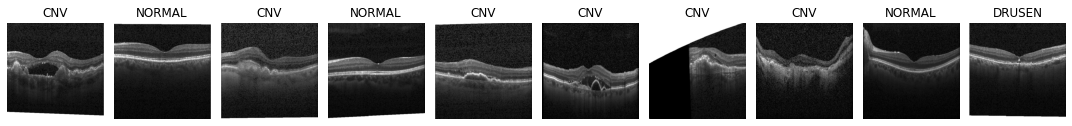

Conjunto de Validação:


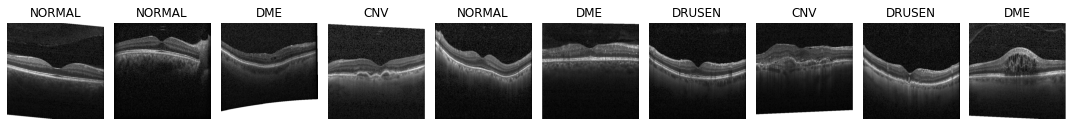

In [26]:
num_row = 1
num_col = 10
num = num_row*num_col

print('Conjunto de Treino:')
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
exemplo_gen = next(train_generator_vanilla)
X = exemplo_gen[0]
y = exemplo_gen[1]
for i in range(num):
  ax = axes[i%num_col]
  ax.imshow(X[i, :, :, 0], cmap='gray', vmin = 0, vmax = 1)
  ax.set_title(inverse_one_hot_encoder_labels(y[i]))
  ax.set_axis_off()
plt.tight_layout()
plt.show()

print('Conjunto de Validação:')
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
exemplo_gen = next(valid_generator_vanilla)
X = exemplo_gen[0]
y = exemplo_gen[1]
for i in range(num):
  ax = axes[i%num_col]
  ax.imshow(X[i, :, :, 0], cmap='gray', vmin = 0, vmax = 1)
  ax.set_title(inverse_one_hot_encoder_labels(y[i]))
  ax.set_axis_off()
plt.tight_layout()
plt.show()

Sem Tratamento:


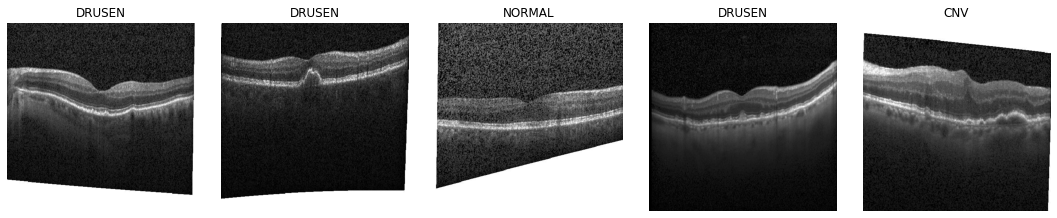

Com Tratamento:


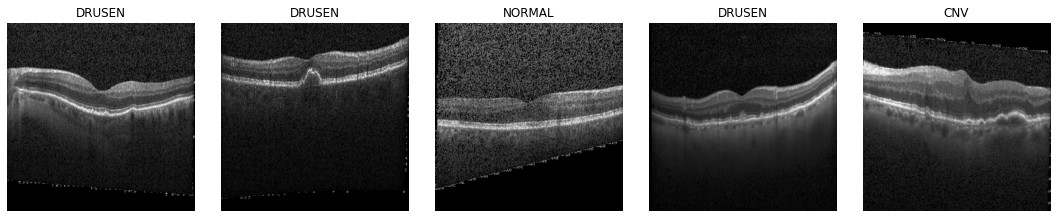

In [27]:
#Exemplo de Tratamento de Bordas
num_row = 1
num_col = 5
num = num_row*num_col

exemplo_gen = next(train_generator_vanilla)
X = exemplo_gen[0]
y = exemplo_gen[1]

print('Sem Tratamento:')
fig, axes = plt.subplots(num_row, num_col, figsize=(3*num_col,3*num_row))
for i in range(num):
  ax = axes[i%num_col]
  ax.imshow(X[i, :, :, 0], cmap='gray', vmin = 0, vmax = 1)
  ax.set_title(inverse_one_hot_encoder_labels(y[i]))
  ax.set_axis_off()
plt.tight_layout()
plt.show()

print('Com Tratamento:')
fig, axes = plt.subplots(num_row, num_col, figsize=(3*num_col,3*num_row))
for i in range(num):
  ax = axes[i%num_col]
  ax.imshow(elimina_bordas_brancas(X[i, :, :, 0]*255.0), cmap='gray', vmin = 0, vmax = 255)
  ax.set_title(inverse_one_hot_encoder_labels(y[i]))
  ax.set_axis_off()
plt.tight_layout()
plt.show()

#Extrator de Características Baseline: ResNet50V2

In [28]:
loadnet = tf.keras.applications.ResNet50V2(input_shape = (shape_reduzido[0], shape_reduzido[1], 3), include_top = False, weights = 'imagenet')
loadnet.trainable = False

#Adiciona uma GlobalAveragePooling2D no final (redução das features extraídas)
featurenet = tf.keras.Sequential([loadnet, tf.keras.layers.GlobalAveragePooling2D()])
featurenet.summary()

#Guarda quantas features temos no final da rede
featurenet_output_shape = featurenet.layers[-1].get_output_shape_at(0)
shape_featurenet_flat = np.prod(featurenet_output_shape[1:])
print(shape_featurenet_flat)

94674944/94668760 [==============================] - 1s 0us/step
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50v2 (Functional)      (None, 16, 16, 2048)      23564800  
_________________________________________________________________
global_average_pooling2d (Gl (None, 2048)              0         
Total params: 23,564,800
Trainable params: 0
Non-trainable params: 23,564,800
_________________________________________________________________
2048


In [29]:
#Salva a arquitetura da rede e seus pesos
featurenet_json = featurenet.to_json()
with open(path_notebook + 'featurenet.json', "w") as json_file:
    json_file.write(featurenet_json)
featurenet.save_weights(path_notebook + 'featurenet.h5')

/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


In [30]:
#Carrega a arquitetura da rede e seus pesos
with open(path_notebook + 'featurenet.json', 'r') as json_file:
  featurenet_json = json_file.read()
featurenet = tf.keras.models.model_from_json(featurenet_json)
featurenet.load_weights(path_notebook + 'featurenet.h5')

In [31]:
#Exemplo de Extração de Features em um Batch do ImageGenerator

exemplo_gen = next(train_generator_vanilla)
X = exemplo_gen[0]
X = np.repeat(X[:, :, :, 0, np.newaxis], 3, -1) #Faz virar imagens de 3 canais
y = exemplo_gen[1]

featurenet.predict(X).reshape(batch_size, shape_featurenet_flat)

array([[3.68632555e-01, 9.40057933e-02, 3.55810951e-03, ...,
        0.00000000e+00, 6.67856634e-01, 1.02387674e-01],
       [2.58684009e-01, 4.53392044e-02, 1.50234848e-02, ...,
        1.12820556e-03, 1.09315187e-01, 4.34888108e-03],
       [1.24809435e-02, 1.58270255e-01, 2.05505565e-02, ...,
        5.68144880e-02, 4.31398571e-01, 4.36278991e-03],
       ...,
       [4.48043793e-02, 0.00000000e+00, 0.00000000e+00, ...,
        7.26811290e-02, 2.02194422e-01, 5.79942241e-02],
       [1.97572391e-02, 5.81419393e-02, 2.40650643e-02, ...,
        1.02261370e-02, 3.60526919e-01, 4.15499846e-04],
       [1.26241013e-01, 9.46558416e-02, 8.89261067e-03, ...,
        2.96063232e-03, 2.74369419e-02, 3.07647288e-02]], dtype=float32)

In [32]:
# Extração de Features direto dos arquivos das imagens
def extracao_features_baseline(df_paths, batch_size, featurenet):
  featurenet_output_shape = featurenet.layers[-1].get_output_shape_at(0)
  shape_featurenet_flat = np.prod(featurenet_output_shape[1:])
  
  x_conj = np.empty(shape = (0, shape_featurenet_flat))
  y_conj = np.array([])

  num_loop = int(np.ceil(len(df_paths)/batch_size))
  for i in range(0, num_loop):

    if(i < num_loop-1):
      paths = df_paths.iloc[i*batch_size:(i+1)*batch_size]['Caminho'].values
    else:
      paths = df_paths.iloc[i*batch_size:]['Caminho'].values

    batch = []
    for path in paths:
      #Carrega a Imagem e faz o preprocessamento (no caso é só reshape)
      X = np.array(Image.open(path).resize(shape_reduzido))/255.0 #como o reshape é quadrado, não precisamos inverter no reshape do PIL
      #OBS: lembrar que shapes de imagem são invertidos do shape de matrizes (linha, coluna) -> (coluna, linha)
      X = np.repeat(X[:, :, np.newaxis], 3, -1) #Faz virar imagens de 3 canais
      batch.append(X)
    batch = np.array(batch)

    x_conj = np.concatenate((x_conj, featurenet.predict(batch).reshape(len(batch), shape_featurenet_flat)), axis = 0)

    if(i < num_loop-1):
      y_conj = np.append(y_conj, df_paths.iloc[i*batch_size:(i+1)*batch_size]['Label_Arquivo'])
    else:
      y_conj = np.append(y_conj, df_paths.iloc[i*batch_size:]['Label_Arquivo'])

    del batch, X
    gc.collect()

  return x_conj, y_conj

In [33]:
#Define o batch de arquivos que vamos carregar por iteração
batch_size_iter = batch_size*(2**3)

In [34]:
#Lê os arquivos e faz a extração de características
#(Aqui terminamos com nosso conjunto de treino/validação com as features extraídas)

x_train, y_train = extracao_features_baseline(df_paths[df_paths['Novo_Conjunto'] == 'train'][['Caminho', 'Label_Arquivo']], 
                                              batch_size_iter, featurenet)
y_ohe_train = np.array([one_hot_encoder(y) for y in y_train])

x_val, y_val = extracao_features_baseline(df_paths[df_paths['Novo_Conjunto'] == 'val'][['Caminho', 'Label_Arquivo']], 
                                          batch_size_iter, featurenet)
y_ohe_val = np.array([one_hot_encoder(y) for y in y_val])

#Modelos Baseline: Rede Neural Fully-Connected

In [35]:
means_train = np.mean(x_train, axis = 0)
stds_train = np.std(x_train, axis = 0)
joblib.dump([means_train, stds_train], path_notebook + 'normalizacao_nn.pkl')

['/content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/01-Baseline/normalizacao_nn.pkl']

In [36]:
means_train, stds_train = joblib.load(path_notebook + 'normalizacao_nn.pkl')
flag_valido = stds_train != 0
means_train = means_train[flag_valido]
stds_train = stds_train[flag_valido]

In [37]:
#Construção da rede fully-connected

input_shape = np.sum(flag_valido)
output_shape = len(classes)

model_baseline_nn = tf.keras.models.Sequential()
model_baseline_nn.add(tf.keras.layers.Dense(output_shape, activation = 'softmax', input_shape=(input_shape,)))
model_baseline_nn.summary()

opt = tf.keras.optimizers.SGD(learning_rate = 0.01)
model_baseline_nn.compile(loss = 'categorical_crossentropy', optimizer = opt, metrics = ['accuracy'])

model_baseline_nn_json = model_baseline_nn.to_json()
with open(path_notebook + 'model_baseline_nn.json', "w") as json_file:
    json_file.write(model_baseline_nn_json)

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 4)                 8192      
Total params: 8,192
Trainable params: 8,192
Non-trainable params: 0
_________________________________________________________________


In [38]:
#Calcula o pesos das classes para o treinamento
class_weights = compute_class_weight('balanced', classes, y_train)
train_class_weights = dict(enumerate(class_weights))
print(train_class_weights)

{0: 0.561068189452469, 1: 1.83852504127683, 2: 2.421075518191042, 3: 0.7931902364896951}


In [39]:
#Treina a rede e salva os pesos obtidos para a melhor época do treinamento
#Salva também a curva de viés-variância do treinamento

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = path_notebook + 'weights_baseline.h5',
    save_weights_only = True,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1)

epochs = 50
H = model_baseline_nn.fit((x_train[:, flag_valido] - means_train)/stds_train, y_ohe_train,
                          validation_data = ((x_val[:, flag_valido] - means_train)/stds_train, y_ohe_val), 
                          class_weight = train_class_weights,
                          callbacks=[model_checkpoint_callback],
                          batch_size = batch_size, epochs = epochs, 
                          verbose = 1)

joblib.dump(H.history, path_notebook + 'history.pkl')
gc.collect()

Instructions for updating:
The `validate_indices` argument has no effect. Indices are always validated on CPU and never validated on GPU.
Epoch 1/50
2088/2088 [==============================] - 7s 3ms/step - loss: 0.4340 - accuracy: 0.8489 - val_loss: 0.3360 - val_accuracy: 0.8778

Epoch 00001: val_loss improved from inf to 0.33604, saving model to /content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/01-Baseline/weights_baseline.h5
Epoch 2/50
[... 187 linhas omitidas na versão pública ...]
Epoch 49/50
2088/2088 [==============================] - 6s 3ms/step - loss: 0.1945 - accuracy: 0.9297 - val_loss: 0.3098 - val_accuracy: 0.9034

Epoch 00049: val_loss did not improve from 0.27382
Epoch 50/50
2088/2088 [==============================] - 6s 3ms/step - loss: 0.1950 - accuracy: 0.9293 - val_loss: 0.3113 - val_accuracy: 0.9027

Epoch 00050: val_loss did not improve from 0.27382


2122

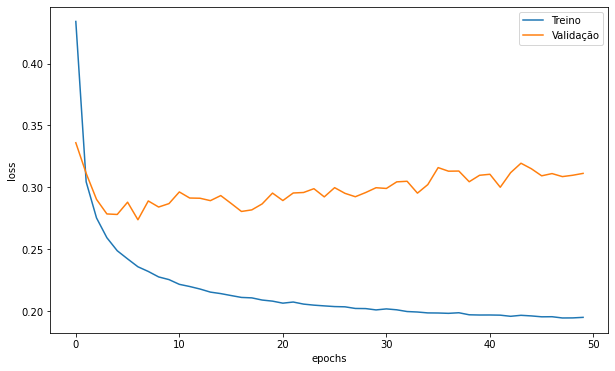

Loss Mínima: 0.27381789684295654
Época da Loss Mínima: 7


In [40]:
#Carrega os pesos da rede e a curva de viés-variância do treinamento
with open(path_notebook + 'model_baseline_nn.json', 'r') as json_file:
  model_baseline_nn_json = json_file.read()
model_baseline_nn = tf.keras.models.model_from_json(model_baseline_nn_json)
model_baseline_nn.load_weights(path_notebook + 'weights_baseline.h5')
history = joblib.load(path_notebook + 'history.pkl')

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)                 
ax.plot(history['loss'], label = 'Treino')
ax.plot(history['val_loss'], label = 'Validação')
ax.set_xlabel('epochs')
ax.set_ylabel('loss')
ax.legend()
plt.show()

print('Loss Mínima: ' + str(np.min(history['val_loss'])))
print('Época da Loss Mínima: ' + str(1 + np.argmin(history['val_loss'])))

In [41]:
#Define a função de avaliação dos modelos em um conjunto (Calcula acurácia, acurácia balanceada e a matriz de confusão)
def evaluate(y, preds, labels = None, normalize = True):
    # Cálculo das métricas de acerto.
    print('Accuracy:', metrics.accuracy_score(y, preds).round(3))
    print('Accuracy (balanced):', metrics.balanced_accuracy_score(y, preds).round(3))
    
    # Calculo da matriz de confusão.
    r = metrics.confusion_matrix(y, preds)
    if(normalize):
      r = r / r.sum(axis = 1, keepdims = True)
    
    #Evita Erro quando um dos Labels não está presente no conjunto y avaliado ou na predição
    labels_x = [l for l in labels if l in list(np.unique(preds))]
    labels_y = [l for l in labels if l in list(np.unique(y))]
    if(len(labels_x) >= len(labels_y)):
      labels = labels_x
    else:
      labels = labels_y

    # Impressão dos gráficos.
    if(normalize):
      (plt
      .figure(figsize=(8, 6))
      .suptitle('Matriz de confusão', fontsize=20))
      sns.heatmap(r,
                  cmap = "YlGnBu", linewidths = .5, annot = True, fmt = ".1%",
                  xticklabels = labels, yticklabels = labels, cbar = False)
    else:
      (plt
      .figure(figsize=(8, 6))
      .suptitle('Matriz de confusão', fontsize=20))
      sns.heatmap(r,
                  cmap = "YlGnBu", linewidths = .5, annot = True, fmt = "",
                  xticklabels = labels, yticklabels = labels, cbar = False)
    plt.show()

Treino:
Accuracy: 0.927
Accuracy (balanced): 0.924


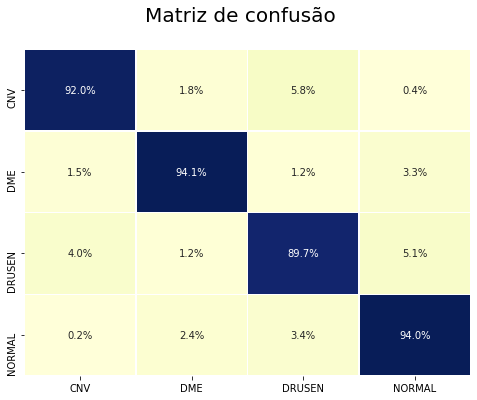

Validação:
Accuracy: 0.905
Accuracy (balanced): 0.891


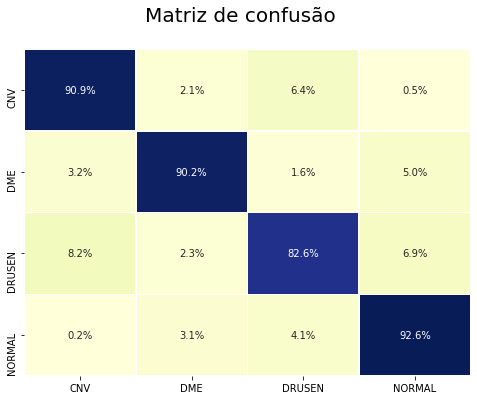

In [42]:
print('Treino:')
evaluate(y_train, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict((x_train[:, flag_valido] - means_train)/stds_train)]), labels = classes)

print('Validação:')
evaluate(y_val, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict((x_val[:, flag_valido] - means_train)/stds_train)]), labels = classes)

#Modelos Baseline: Catboost

In [ ]:
!pip install catboost

     |████████████████████████████████| 69.2MB 86kB/s 


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
#Calcula os pesos das classes para o treinamento
class_weights = compute_class_weight('balanced', classes, y_train)
train_class_weights = dict([(classes[i],class_weights[i]) for i in range(0, len(classes))])
print(train_class_weights)

{'CNV': 0.561068189452469, 'DME': 1.83852504127683, 'DRUSEN': 2.421075518191042, 'NORMAL': 0.7931902364896951}


In [ ]:
#Instancia um classificação com os hiperparâmetros padrões
clf_cat = CatBoostClassifier(class_weights = train_class_weights)

In [ ]:
#Treina o catboost e salva o modelo após o treinamento
#Salva também a curva de viés-variância do treinamento

clf_cat.fit(x_train, y_train, eval_set = (x_val, y_val), early_stopping_rounds = 50, verbose = True, plot = False)
joblib.dump(clf_cat, path_notebook + 'catboost_baseline.pkl')

history = {}
history['loss'] = clf_cat.get_evals_result()['learn']['MultiClass']
history['val_loss'] = clf_cat.get_evals_result()['validation']['MultiClass']

joblib.dump(history, path_notebook + 'history_cat.pkl')

Custom logger is already specified. Specify more than one logger at same time is not thread safe.

Learning rate set to 0.117442
0:	learn: 1.2915876	test: 1.2917556	best: 1.2917556 (0)	total: 2.78s	remaining: 46m 21s
1:	learn: 1.2169988	test: 1.2179250	best: 1.2179250 (1)	total: 4.99s	remaining: 41m 32s
2:	learn: 1.1595132	test: 1.1603902	best: 1.1603902 (2)	total: 7.16s	remaining: 39m 38s
3:	learn: 1.1098539	test: 1.1118408	best: 1.1118408 (3)	total: 9.5s	remaining: 39m 25s
4:	learn: 1.0612564	test: 1.0624540	best: 1.0624540 (4)	total: 11.7s	remaining: 38m 52s
5:	learn: 1.0229385	test: 1.0245857	best: 1.0245857 (5)	total: 13.8s	remaining: 38m 8s
6:	learn: 0.9902488	test: 0.9917298	best: 0.9917298 (6)	total: 16s	remaining: 37m 53s
[... 990 linhas omitidas na versão pública ...]
997:	learn: 0.1809111	test: 0.3165045	best: 0.3164695 (996)	total: 28m 25s	remaining: 3.42s
998:	learn: 0.1808195	test: 0.3165023	best: 0.3164695 (996)	total: 28m 27s	remaining: 1.71s
999:	learn: 0.1806934	test: 0.3165820	best: 0.3164695 (996)	total: 28m 28s	remaining: 0us

bestTest = 0.3164695274
bestIterati

['/content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/history_cat.pkl']

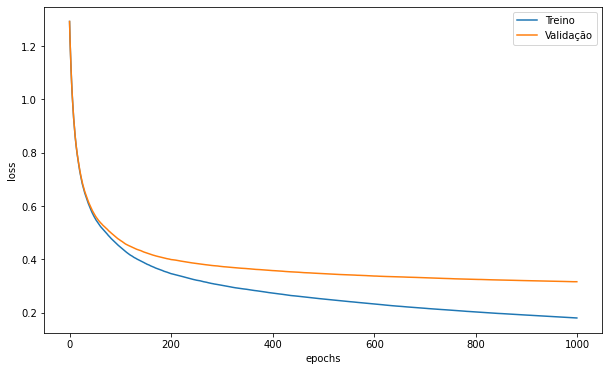

Loss Mínima: 0.3164695274350656
Época da Loss Mínima: 997


In [ ]:
#Carrega o classificar treinamento e a curva de viés-variância

clf_cat = joblib.load(path_notebook + 'catboost_baseline.pkl')
history = joblib.load(path_notebook + 'history_cat.pkl')

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)                 
ax.plot(history['loss'], label = 'Treino')
ax.plot(history['val_loss'], label = 'Validação')
ax.set_xlabel('epochs')
ax.set_ylabel('loss')
ax.legend()
plt.show()

print('Loss Mínima: ' + str(np.min(history['val_loss'])))
print('Época da Loss Mínima: ' + str(1 + np.argmin(history['val_loss'])))

In [ ]:
#Printa os parâmtros do clasificador
clf_cat.get_all_params()

{'auto_class_weights': 'None',
 'bagging_temperature': 1,
 'bayesian_matrix_reg': 0.10000000149011612,
 'best_model_min_trees': 1,
 'boost_from_average': False,
 'boosting_type': 'Plain',
 'bootstrap_type': 'Bayesian',
 'border_count': 254,
[... 29 linhas omitidas na versão pública ...]
 'random_seed': 0,
 'random_strength': 1,
 'rsm': 1,
 'sampling_frequency': 'PerTree',
 'score_function': 'Cosine',
 'sparse_features_conflict_fraction': 0,
 'task_type': 'CPU',
 'use_best_model': True}

Treino:
Accuracy: 0.951
Accuracy (balanced): 0.957


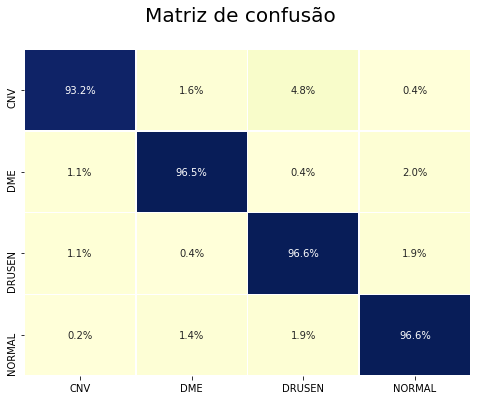

Validação:
Accuracy: 0.906
Accuracy (balanced): 0.886


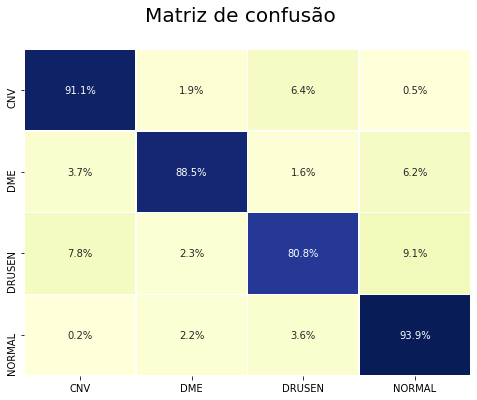

In [ ]:
print('Treino:')
evaluate(y_train, clf_cat.predict(x_train), labels = classes)

print('Validação:')
evaluate(y_val, clf_cat.predict(x_val), labels = classes)

# Avaliação no Teste

In [43]:
#Extrai as features das imagens de teste

x_test, y_test = extracao_features_baseline(df_paths[df_paths['Novo_Conjunto'] == 'test'][['Caminho', 'Label_Arquivo']], 
                                          batch_size_iter, featurenet)
y_ohe_test = np.array([one_hot_encoder(y) for y in y_test])

x_test_hon, y_test_hon = extracao_features_baseline(df_paths[(df_paths['Novo_Conjunto'] == 'test')&
                                                             (df_paths['Teste_Honesto'] == True)][['Caminho', 'Label_Arquivo']], 
                                          batch_size_iter, featurenet)
y_ohe_test_hon = np.array([one_hot_encoder(y) for y in y_test_hon])

Teste (Fully-Connected):
Accuracy: 0.969
Accuracy (balanced): 0.969


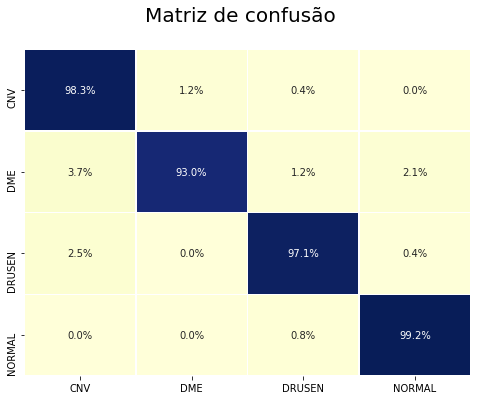

Teste Honesto (Fully-Connected):
Accuracy: 0.951
Accuracy (balanced): 0.966


/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1859: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:10: RuntimeWarning: invalid value encountered in true_divide
  # Remove the CWD from sys.path while we load stuff.


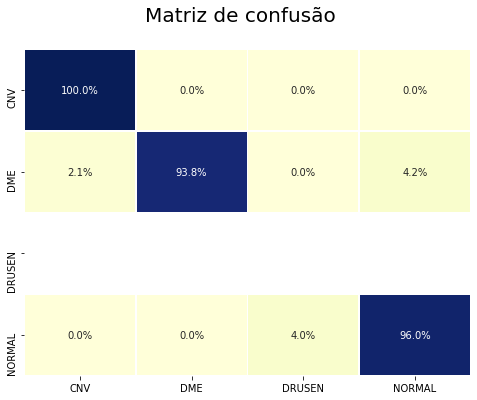

In [44]:
#Avalia a rede Fully-Connected no teste

print('Teste (Fully-Connected):')
evaluate(y_test, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict((x_test[:, flag_valido] - means_train)/stds_train)]), labels = classes)

print('Teste Honesto (Fully-Connected):')
evaluate(y_test_hon, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict((x_test_hon[:, flag_valido] - means_train)/stds_train)]), labels = classes)

Teste (Catboost):
Accuracy: 0.974
Accuracy (balanced): 0.974


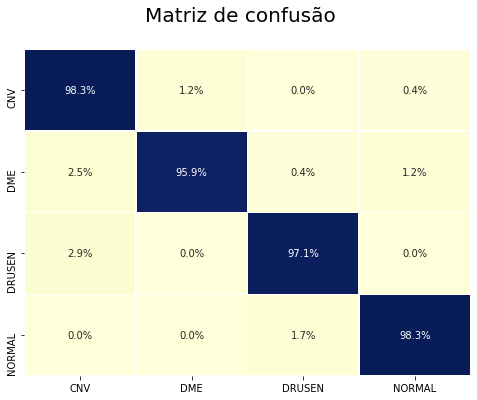

Teste Honesto (Catboost):
Accuracy: 0.963
Accuracy (balanced): 0.979


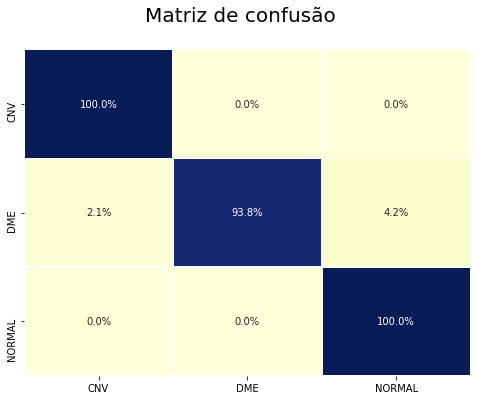

In [ ]:
#Avalia o Catboost no teste

print('Teste (Catboost):')
evaluate(y_test, clf_cat.predict(x_test), labels = classes)

print('Teste Honesto (Catboost):')
evaluate(y_test_hon, clf_cat.predict(x_test_hon), labels = classes)